Install and import required package and libraries

In [1]:
# For data processing

import numpy as np
import pandas as pd

In [2]:
# For statistics and econometrics

%pip install statsmodels scipy
import os
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.rolling import RollingOLS

Note: you may need to restart the kernel to use updated packages.


In [3]:
# For machine learning models

%pip install scikit-learn
%pip install -U scikit-learn joblib
%pip install tensorflow
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [4]:
# For visualization

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

In [5]:
# Other utilities

%pip install tqdm
from tqdm import tqdm
import joblib
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

Note: you may need to restart the kernel to use updated packages.


Constructing models

1. CAPM

In [ ]:
DATA_PATH = "Master_Panel.csv"
OUT_DIR = r"./sector_capm_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

DATE_COL = "YearMonth"
SECTOR_COL = "Sector"  
WEIGHT_COL = "Market Capital (Bn. VND)" 
Y_COL = "excess_return"
X_COL = "mkt_excess"

# Expanding-window prediction settings
MIN_WINDOW = 24             
TEST_END_MONTHS = 24        
NW_LAGS = 3                 

def load_and_aggregate_sector_data():
    print("Loading and aggregating data...")
    df = pd.read_csv(DATA_PATH)
    
    # Robust Date Parsing
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
    
    # Clean Sector Strings
    df[SECTOR_COL] = df[SECTOR_COL].astype(str).str.strip()
    
    # Drop rows missing essential data
    df.dropna(subset=[SECTOR_COL, DATE_COL, Y_COL, X_COL, WEIGHT_COL], inplace=True)
    
    def weighted_avg(x):
        weights = x[WEIGHT_COL] / x[WEIGHT_COL].sum()
        return np.sum(x[Y_COL] * weights)

    # Group by Sector and Date to create the portfolio
    sector_df = df.groupby([SECTOR_COL, DATE_COL]).apply(
        lambda x: pd.Series({
            Y_COL: weighted_avg(x),           # Weighted Sector Excess Return
            X_COL: x[X_COL].iloc[0],          # Market Excess 
            'market_return': x['market_return'].iloc[0],
            'rf': x['rf'].iloc[0]
        })
    ).reset_index()

    # Sort
    sector_df = sector_df.sort_values([SECTOR_COL, DATE_COL]).reset_index(drop=True)
    print(f"Data aggregated into {sector_df[SECTOR_COL].nunique()} sectors.")
    return sector_df

def expanding_alpha_beta(x: np.ndarray, y: np.ndarray):
    n = len(x)
    alpha = np.full(n, np.nan, dtype=float)
    beta  = np.full(n, np.nan, dtype=float)

    sx  = np.cumsum(x)
    sy  = np.cumsum(y)
    sxx = np.cumsum(x * x)
    sxy = np.cumsum(x * y)

    for t in range(1, n):
        n_hist = t 
        sum_x  = sx[t-1]
        sum_y  = sy[t-1]
        sum_xx = sxx[t-1]
        sum_xy = sxy[t-1]

        denom = (sum_xx - (sum_x * sum_x) / n_hist)
        if denom == 0: continue

        beta_t = (sum_xy - (sum_x * sum_y) / n_hist) / denom
        alpha_t = (sum_y / n_hist) - beta_t * (sum_x / n_hist)

        beta[t] = beta_t
        alpha[t] = alpha_t

    return alpha, beta

def run_analysis():
    # 1. Prepare Sector Data
    capm = load_and_aggregate_sector_data()
    
    # 2. Setup Testing Window
    all_months = capm[DATE_COL].dropna().sort_values().unique()
    test_months = all_months[-TEST_END_MONTHS:]
    test_start_date = test_months[0]
    
    pred_rows = []
    
    print("Running Expanding Window Backtest...")
    # 3. Expanding Window Loop
    for sector, g in capm.groupby(SECTOR_COL, sort=False):
        g = g.sort_values(DATE_COL).reset_index(drop=True)
        
        x = g[X_COL].to_numpy(dtype=float)
        y = g[Y_COL].to_numpy(dtype=float)
        d = g[DATE_COL].to_numpy()
        
        n = len(g)
        if n <= MIN_WINDOW: continue
            
        alpha_hat, beta_hat = expanding_alpha_beta(x, y)
        
        # Calculate historical mean of market excess for prediction
        x_cum = np.cumsum(x)
        x_mean_past = np.full(n, np.nan, dtype=float)
        for t in range(1, n):
            x_mean_past[t] = x_cum[t-1] / t
            
        # Benchmark: Historical mean of sector excess return
        y_cum = np.cumsum(y)
        y_bench = np.full(n, np.nan, dtype=float)
        for t in range(1, n):
            y_bench[t] = y_cum[t-1] / t
            
        for t in range(MIN_WINDOW, n):
            date_t = pd.Timestamp(d[t])
            if date_t < test_start_date: continue
            
            a = alpha_hat[t]
            b = beta_hat[t]
            mx = x_mean_past[t] # Using historical average market return expectation
            
            if np.isnan(a) or np.isnan(b) or np.isnan(mx): continue
            
            # CAPM Prediction: E[R] = Alpha + Beta * E[Rm]
            y_pred = a + b * mx
            
            pred_rows.append({
                "sector": sector,
                "date": date_t,
                "actual_excess_return": y[t],
                "capm_pred_return": y_pred,
                "benchmark_pred_return": y_bench[t],
                "alpha_rolling": a,
                "beta_rolling": b
            })
            
    pred_df = pd.DataFrame(pred_rows)
    pred_df.to_csv(os.path.join(OUT_DIR, "sector_capm_predictions.csv"), index=False)
    
    # 4. Full Sample Regression (Newey-West)
    print("Running Full Sample Regressions...")
    beta_rows = []
    
    for sector, g in capm.groupby(SECTOR_COL, sort=False):
        g = g.dropna(subset=[Y_COL, X_COL])
        if len(g) < MIN_WINDOW: continue
            
        y = g[Y_COL].astype(float)
        X = sm.add_constant(g[X_COL].astype(float))
        
        # HAC Standard Errors
        model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": NW_LAGS})
        
        beta_rows.append({
            "sector": sector,
            "n_obs": int(model.nobs),
            "alpha": model.params["const"],
            "beta": model.params[X_COL],
            "beta_t_stat": model.tvalues[X_COL],
            "beta_p_value": model.pvalues[X_COL],
            "adj_r2": model.rsquared_adj
        })
        
    betas_full = pd.DataFrame(beta_rows).sort_values("beta", ascending=False)
    betas_full.to_csv(os.path.join(OUT_DIR, "sector_capm_betas.csv"), index=False)
    
    # 5. Visualization
    create_visualizations(betas_full, pred_df)
    
    return betas_full, pred_df

def create_visualizations(betas_df, pred_df):
    sns.set_style("whitegrid")
    
    # Plot 1: Sector Betas (Risk Sensitivity)
    plt.figure(figsize=(12, 6))
    colors = ['red' if x > 1 else 'blue' for x in betas_df['beta']]
    sns.barplot(x='beta', y='sector', data=betas_df, palette=colors)
    plt.axvline(1.0, color='black', linestyle='--')
    plt.title("CAPM Beta by Sector (Systematic Risk Sensitivity)")
    plt.xlabel("Beta (>1: Aggressive, <1: Defensive)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "sector_betas_plot.png"))
    plt.close()

    # Plot 2: Realized vs Predicted Returns (Aggregated Scatter)
    plt.figure(figsize=(8, 8))
    sns.scatterplot(x='capm_pred_return', y='actual_excess_return', data=pred_df, hue='sector', alpha=0.6)
    
    # 45-degree line for perfect prediction
    lims = [
        np.min([pred_df['capm_pred_return'].min(), pred_df['actual_excess_return'].min()]),
        np.max([pred_df['capm_pred_return'].max(), pred_df['actual_excess_return'].max()])
    ]
    plt.plot(lims, lims, 'k--', alpha=0.75, zorder=0)
    plt.title("Out-of-Sample: Predicted vs Actual Sector Returns")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "oos_prediction_accuracy.png"))
    plt.close()
    
    print("Visualizations saved.")

# Execute
if __name__ == "__main__":
    betas, predictions = run_analysis()
    print("\n--- Summary of Sector Betas ---")
    print(betas[['sector', 'alpha', 'beta', 'adj_r2']].head())

Loading and aggregating data...
Data aggregated into 11 sectors.
Running Expanding Window Backtest...
Running Full Sample Regressions...
Visualizations saved.

--- Summary of Sector Betas ---
                            sector     alpha      beta    adj_r2
10                       Tài chính  0.014626  1.498501  0.695046
9                       Năng lượng  0.009379  1.437070  0.496978
8                  Nguyên vật liệu  0.011210  1.207578  0.721908
0                     Bất động sản  0.010202  1.062850  0.714606
6   Hàng tiêu dùng không thiết yếu  0.006685  0.979770  0.620623


2. Fama French

In [ ]:
DATA_PATH = "Master_Panel.csv"
OUT_DIR = r"./sector_ff3_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

DATE_COL = "YearMonth"
SECTOR_COL = "Sector"
TICKER_COL = "ticker"

# Required columns
Y_COL = "excess_return"           # stock excess return (R_i - Rf)
MKT_COL = "mkt_excess"            # market excess return (Rm - Rf)
SIZE_COL = "Market Capital (Bn. VND)"  # firm size proxy
PB_COL = "P/B"                         # used to derive B/M

# Testing Settings
MIN_WINDOW = 24
TEST_END_MONTHS = 24
NW_LAGS = 3

# Factor Breakpoints (Fama-French Standard)
VALUE_LOW_Q = 0.30
VALUE_HIGH_Q = 0.70

def load_and_prep_data():
    """Loads and cleans the panel for factor construction."""
    print("Step 1: Loading Data...")
    df = pd.read_csv(DATA_PATH)
    
    # Robust Date Parsing
    df[DATE_COL] = pd.to_datetime(df[DATE_COL].astype(str), errors="coerce")
    df[SECTOR_COL] = df[SECTOR_COL].astype(str).str.strip()
    
    # Filter necessary columns
    need = [TICKER_COL, SECTOR_COL, DATE_COL, Y_COL, MKT_COL, SIZE_COL, PB_COL]
    panel = df[need].dropna().copy()
    
    # Ensure Numeric
    for c in [Y_COL, MKT_COL, SIZE_COL, PB_COL]:
        panel[c] = pd.to_numeric(panel[c], errors="coerce")
        
    # Create Book-to-Market (B/M)
    # B/M is the inverse of P/B
    panel["bm"] = np.where(panel[PB_COL] > 0, 1.0 / panel[PB_COL], np.nan)
    
    # Sort
    panel = panel.sort_values([TICKER_COL, DATE_COL]).reset_index(drop=True)
    return panel

def construct_market_factors(panel):
    print("Step 2: Constructing Fama-French Factors (SMB, HML)...")
    
    def vw_return(r, w):
        """Value-Weighted Return Helper"""
        mask = np.isfinite(r) & np.isfinite(w) & (w > 0)
        if mask.sum() < 1: return np.nan
        return np.sum(w[mask] * r[mask]) / np.sum(w[mask])

    rows = []
    # Group by Month
    for date, g in panel.groupby(DATE_COL):
        if len(g) < 10: continue # Skip months with insufficient data
        
        # Calculate Breakpoints for this month
        size_med = g[SIZE_COL].median()
        bm_low = g["bm"].quantile(VALUE_LOW_Q)
        bm_high = g["bm"].quantile(VALUE_HIGH_Q)
        
        # Assign Buckets
        g = g.copy()
        g["size_bin"] = np.where(g[SIZE_COL] <= size_med, "S", "B")
        g["value_bin"] = np.select(
            [(g["bm"] <= bm_low), (g["bm"] >= bm_high)], 
            ["L", "H"], 
            default="M"
        )
        
        # Calculate Returns for 6 Portfolios (S/L, S/M, S/H, B/L, B/M, B/H)
        port_rets = {}
        for s in ["S", "B"]:
            for v in ["L", "M", "H"]:
                sub = g[(g["size_bin"]==s) & (g["value_bin"]==v)]
                port_rets[(s,v)] = vw_return(sub[Y_COL].values, sub[SIZE_COL].values)
        
        # SMB = Average(Small Portfolios) - Average(Big Portfolios)
        smb = np.nanmean([port_rets[("S","L")], port_rets[("S","M")], port_rets[("S","H")]]) - \
              np.nanmean([port_rets[("B","L")], port_rets[("B","M")], port_rets[("B","H")]])
              
        # HML = Average(High B/M) - Average(Low B/M)
        hml = np.nanmean([port_rets[("S","H")], port_rets[("B","H")]]) - \
              np.nanmean([port_rets[("S","L")], port_rets[("B","L")]])
        
        rows.append({"date": date, "SMB": smb, "HML": hml})
    
    factors = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
    factors.to_csv(os.path.join(OUT_DIR, "ff3_factors_constructed.csv"), index=False)
    return factors

def aggregate_sector_returns(panel):
    """
    Aggregates individual stocks into Sector Portfolios (Value-Weighted).
    """
    print("Step 3: Aggregating Data to Sector Level...")
    
    def weighted_avg(x):
        return np.sum(x[Y_COL] * x[SIZE_COL]) / np.sum(x[SIZE_COL])
        
    sector_df = panel.groupby([SECTOR_COL, DATE_COL]).apply(
        lambda x: pd.Series({
            Y_COL: weighted_avg(x),           # Value-Weighted Excess Return
            MKT_COL: x[MKT_COL].iloc[0]       # Market Excess is constant
        })
    ).reset_index()
    
    return sector_df

def run_sector_regressions(sector_panel):
    """
    Runs Expanding Window and Full Sample OLS for each Sector.
    """
    print("Step 4: Running Factor Regressions...")
    
    # Sort dates for time-series analysis
    unique_dates = np.sort(sector_panel[DATE_COL].unique())
    test_start = unique_dates[-TEST_END_MONTHS]
    
    pred_rows = []
    beta_rows = []
    
    for sector, g in sector_panel.groupby(SECTOR_COL):
        g = g.sort_values(DATE_COL).dropna()
        if len(g) < MIN_WINDOW: continue
        
        # Prepare Data
        y = g[Y_COL].values
        X_factors = g[[MKT_COL, "SMB", "HML"]].values
        dates = g[DATE_COL].values
        n = len(g)
        
        # A. Expanding Window Backtest
        factor_means = np.zeros_like(X_factors)
        for t in range(1, n):
            factor_means[t] = np.mean(X_factors[:t], axis=0)
            
        for t in range(MIN_WINDOW, n):
            if dates[t] < test_start: continue
            
            # Train on history (0 to t-1)
            X_train = sm.add_constant(X_factors[:t])
            y_train = y[:t]
            
            try:
                model = sm.OLS(y_train, X_train).fit()
                
                # Predict for time t
                # E[R_t] = alpha + beta * E[Factors_t]
                params = model.params
                pred_ret = params[0] + np.dot(params[1:], factor_means[t])
                
                pred_rows.append({
                    "sector": sector,
                    "date": dates[t],
                    "actual_return": y[t],
                    "predicted_return": pred_ret,
                    "alpha_rolling": params[0],
                    "beta_mkt": params[1],
                    "beta_smb": params[2],
                    "beta_hml": params[3]
                })
            except:
                continue
                
        # B. Full Sample Regression (HAC)
        X_full = sm.add_constant(X_factors)
        model_full = sm.OLS(y, X_full).fit(cov_type='HAC', cov_kwds={'maxlags': NW_LAGS})
        
        beta_rows.append({
            "sector": sector,
            "n_obs": int(model_full.nobs),
            "alpha": model_full.params[0],
            "beta_mkt": model_full.params[1],
            "beta_smb": model_full.params[2],
            "beta_hml": model_full.params[3],
            "p_alpha": model_full.pvalues[0],
            "p_mkt": model_full.pvalues[1],
            "p_smb": model_full.pvalues[2],
            "p_hml": model_full.pvalues[3],
            "adj_r2": model_full.rsquared_adj
        })
        
    return pd.DataFrame(pred_rows), pd.DataFrame(beta_rows)

def plot_results(beta_df, pred_df):
    print("Step 5: Generating Visualizations...")
    sns.set_style("whitegrid")
    
    # 1. SMB Beta (Size Sensitivity)
    plt.figure(figsize=(12, 6))
    beta_df_sorted = beta_df.sort_values("beta_smb", ascending=False)
    colors = ['green' if x > 0 else 'red' for x in beta_df_sorted['beta_smb']]
    sns.barplot(x='beta_smb', y='sector', data=beta_df_sorted, palette=colors)
    plt.axvline(0, color='black', linewidth=1)
    plt.title("Sector Sensitivity to Size (SMB Beta)\n(Positive = Behaves like Small Cap, Negative = Behaves like Large Cap)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "sector_smb_betas.png"))
    plt.close()
    
    # 2. HML Beta (Value Sensitivity)
    plt.figure(figsize=(12, 6))
    beta_df_sorted = beta_df.sort_values("beta_hml", ascending=False)
    colors = ['blue' if x > 0 else 'orange' for x in beta_df_sorted['beta_hml']]
    sns.barplot(x='beta_hml', y='sector', data=beta_df_sorted, palette=colors)
    plt.axvline(0, color='black', linewidth=1)
    plt.title("Sector Sensitivity to Value (HML Beta)\n(Positive = Behaves like Value Stock, Negative = Behaves like Growth Stock)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "sector_hml_betas.png"))
    plt.close()

if __name__ == "__main__":
    # 1. Load
    panel = load_and_prep_data()
    
    # 2. Construct Factors
    factors = construct_market_factors(panel)
    
    # 3. Aggregate Sectors
    sector_panel = aggregate_sector_returns(panel)
    
    # 4. Merge
    sector_panel = pd.merge(sector_panel, factors, left_on=DATE_COL, right_on="date", how="inner")
    
    # 5. Run Regressions
    predictions, betas = run_sector_regressions(sector_panel)
    
    # 6. Save & Plot
    predictions.to_csv(os.path.join(OUT_DIR, "sector_ff3_predictions.csv"), index=False)
    betas.to_csv(os.path.join(OUT_DIR, "sector_ff3_betas.csv"), index=False)
    
    plot_results(betas, predictions)
    
    print("\nDone. Results saved in:", os.path.abspath(OUT_DIR))
    print(betas[['sector', 'beta_mkt', 'beta_smb', 'beta_hml', 'adj_r2']].head())

Step 1: Loading Data...
Step 2: Constructing Fama-French Factors (SMB, HML)...
Step 3: Aggregating Data to Sector Level...
Step 4: Running Factor Regressions...
Step 5: Generating Visualizations...

Done. Results saved in: d:\NCKH\Code\sector_ff3_outputs
                sector  beta_mkt  beta_smb  beta_hml    adj_r2
0         Bất động sản  0.963150 -0.055634  0.154197  0.714745
1    Chăm sóc sức khỏe  0.139590 -0.477359  0.080727  0.338980
2          Công nghiệp  0.338980 -0.626790  0.112850  0.683626
3  Công nghệ thông tin  0.294679 -0.877881 -0.186334  0.436019
4     Dịch vụ tiện ích  0.282582 -0.577667 -0.096494  0.661925


3. Random Forest

In [ ]:
# Filter warnings for cleaner output
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

DATA_PATH = "Master_Panel.csv"
FACTOR_PATH_CANDIDATES = [
    r"./sector_ff3_outputs/ff3_factors_constructed.csv"            
]
OUT_DIR = r"./sector_rf_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

DATE_COL   = "YearMonth"
TICKER_COL = "ticker"
SECTOR_COL = "Sector"

RET_COL = "excess_return"   # Target variable
MKT_COL = "mkt_excess"      

# Features
FF_SMB = "SMB"
FF_HML = "HML"

# Rolling Windows for Feature Engineering
VOL_WINDOW = 12
MOM_WINDOW = 12

# Testing Protocol
MIN_WINDOW = 24          # Minimum months for training
TEST_END_MONTHS = 24     # Out-of-Sample (OOS) period

# Hyperparameters
RF_PARAMS = dict(
    n_estimators=100,      # Number of trees
    max_depth=5,           # Prevent overfitting
    min_samples_leaf=10,   # Ensure generalization
    max_features="sqrt",
    random_state=42,
    n_jobs=-1              # Parallel processing
)

def load_and_prep_data():
    print("Step 1: Loading Data...")
    df = pd.read_csv(DATA_PATH)
    
    # Standardize formats
    df[DATE_COL] = pd.to_datetime(df[DATE_COL].astype(str), errors="coerce")
    df[TICKER_COL] = df[TICKER_COL].astype(str).str.upper().str.strip()
    df[SECTOR_COL] = df[SECTOR_COL].astype(str).str.strip()
    
    # 1. Load Factors (FF3)
    factor_path = None
    for p in FACTOR_PATH_CANDIDATES:
        if os.path.exists(p):
            factor_path = p
            break
            
    if factor_path:
        print(f"   Using factors from: {factor_path}")
        factors = pd.read_csv(factor_path)
        # Ensure date format matches
        factors["date"] = pd.to_datetime(factors["date"], errors="coerce")
        
        # Merge factors into main panel
        if FF_SMB not in df.columns:
            df = df.merge(factors, left_on=DATE_COL, right_on="date", how="inner")
            if "date" in df.columns: df.drop(columns=["date"], inplace=True)
    else:
        print("   Warning: Factor file not found. Relying on columns in main file.")

    # 2. Feature Engineering
    print("Step 2: Feature Engineering...")
    df = df.sort_values([TICKER_COL, DATE_COL]).reset_index(drop=True)
    
    # A. Volatility (Risk)
    df["vol_12m"] = (
        df.groupby(TICKER_COL)[RET_COL]
        .rolling(VOL_WINDOW, min_periods=VOL_WINDOW).std()
        .reset_index(level=0, drop=True)
    )
    
    # B. Momentum (Trend)
    df["mom_12m"] = (
        df.groupby(TICKER_COL)[RET_COL]
        .rolling(MOM_WINDOW, min_periods=MOM_WINDOW).sum()
        .reset_index(level=0, drop=True)
    )
    
    # C. Amihud Illiquidity (Cost of Trading)
    # Formula: |Return| / Volume
    if "TradingValue" in df.columns:
        df["amihud"] = np.abs(df[RET_COL]) / (pd.to_numeric(df["TradingValue"], errors="coerce") + 1e-9)
    elif "Volume" in df.columns:
         df["amihud"] = np.abs(df[RET_COL]) / (pd.to_numeric(df["Volume"], errors="coerce") + 1e-9)
    else:
        df["amihud"] = np.abs(df[RET_COL]) # Fallback if volume missing

    # 3. Lag Features (Predict next month using current data)
    features = [MKT_COL, FF_SMB, FF_HML, "vol_12m", "mom_12m", "amihud"]
    
    # Check if features exist
    existing_features = [f for f in features if f in df.columns]
    
    for f in existing_features:
        df[f] = df.groupby(TICKER_COL)[f].shift(1)
        
    # Drop missing data created by lagging/rolling
    df.dropna(subset=existing_features + [RET_COL, SECTOR_COL], inplace=True)
    
    return df, existing_features

def run_sector_rf():
    df, features = load_and_prep_data()
    
    # Setup Testing Dates
    all_months = np.sort(df[DATE_COL].unique())
    test_months = all_months[-TEST_END_MONTHS:]
    
    print(f"Step 3: Training Random Forests by Sector ({len(test_months)} OOS months)...")
    
    pred_rows = []
    fi_rows = [] # Feature Importance
    
    # Iterate over each Sector
    for sector, sector_df in df.groupby(SECTOR_COL):
        if len(sector_df) < 100: continue # Skip tiny sectors
        
        # Expanding Window Loop
        for t in test_months:
            train = sector_df[sector_df[DATE_COL] < t]
            test  = sector_df[sector_df[DATE_COL] == t]
            
            # Need minimum history to train
            if train[DATE_COL].nunique() < MIN_WINDOW or test.empty:
                continue
                
            X_train = train[features]
            y_train = train[RET_COL]
            X_test  = test[features]
            
            # Train Model
            rf = RandomForestRegressor(**RF_PARAMS)
            rf.fit(X_train, y_train)
            
            # Predict
            y_pred = rf.predict(X_test)
            
            # Store Feature Importance
            importances = rf.feature_importances_
            fi_rows.append({
                "sector": sector,
                "date": t,
                **{f: importances[i] for i, f in enumerate(features)}
            })
            
            # Store Predictions
            # Calculate Benchmark (Historical Mean) for comparison
            bench_mean = train[RET_COL].mean()
            
            output_chunk = test[[TICKER_COL, DATE_COL, RET_COL]].copy()
            output_chunk["sector"] = sector
            output_chunk["rf_pred"] = y_pred
            output_chunk["bench_pred"] = bench_mean
            pred_rows.append(output_chunk)
            
    # Compile Results
    pred_df = pd.concat(pred_rows, ignore_index=True)
    fi_df = pd.DataFrame(fi_rows)
    
    # Calculate Metrics
    pred_df["sq_err_rf"] = (pred_df[RET_COL] - pred_df["rf_pred"]) ** 2
    pred_df["sq_err_bench"] = (pred_df[RET_COL] - pred_df["bench_pred"]) ** 2
    
    return pred_df, fi_df

def generate_outputs(pred_df, fi_df):
    print("Step 4: Generating Outputs & Visualizations...")
    
    # 1. Prediction CSV
    pred_df.to_csv(os.path.join(OUT_DIR, "sector_rf_predictions.csv"), index=False)
    
    # 2. Performance Summary by Sector
    sector_perf = pred_df.groupby("sector").apply(
        lambda x: pd.Series({
            "MSE_RF": x["sq_err_rf"].mean(),
            "MSE_Bench": x["sq_err_bench"].mean(),
            "R2_OOS": 1 - (x["sq_err_rf"].sum() / x["sq_err_bench"].sum())
        })
    ).reset_index()
    sector_perf.to_csv(os.path.join(OUT_DIR, "sector_rf_performance.csv"), index=False)
    
    # 3. Feature Importance Summary
    fi_avg = fi_df.drop(columns=["date"]).groupby("sector").mean().reset_index()
    fi_avg.to_csv(os.path.join(OUT_DIR, "sector_rf_feature_importance.csv"), index=False)
    
    # Visualization 1: R2 OOS by Sector
    plt.figure(figsize=(12, 6))
    colors = ['green' if x > 0 else 'red' for x in sector_perf['R2_OOS']]
    sns.barplot(x='R2_OOS', y='sector', data=sector_perf.sort_values('R2_OOS', ascending=False), palette=colors)
    plt.title("Random Forest Out-of-Sample R² by Sector\n(>0 means RF outperform historical mean)")
    plt.axvline(0, color='black')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "rf_r2_oos_by_sector.png"))
    plt.close()
    
    # Visualization 2: Feature Importance Heatmap
    plt.figure(figsize=(10, 8))
    fi_pivot = fi_avg.set_index("sector")
    sns.heatmap(fi_pivot, annot=True, cmap="viridis", fmt=".2f")
    plt.title("Feature Importance by Sector")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "rf_feature_importance_heatmap.png"))
    plt.close()

if __name__ == "__main__":
    predictions, importance = run_sector_rf()
    generate_outputs(predictions, importance)
    print(f"\nAnalysis Complete. Outputs saved to: {os.path.abspath(OUT_DIR)}")

Step 1: Loading Data...
   Using factors from: ./sector_ff3_outputs/ff3_factors_constructed.csv
Step 2: Feature Engineering...
Step 3: Training Random Forests by Sector (24 OOS months)...
Step 4: Generating Outputs & Visualizations...

Analysis Complete. Outputs saved to: d:\NCKH\Code\sector_rf_outputs


4. Neural Network

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

DATA_PATH = "Master_Panel.csv"

FACTOR_PATH_CANDIDATES = [
    r"./sector_ff3_outputs/ff3_factors_constructed.csv"
]

OUT_DIR = r"./sector_nn_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

DATE_COL   = "YearMonth"
TICKER_COL = "ticker"
SECTOR_COL = "Sector"

RET_COL = "excess_return"   # target
MKT_COL = "mkt_excess"

FF_SMB = "SMB"
FF_HML = "HML"

# Testing Protocol
MIN_WINDOW = 24
TEST_END_MONTHS = 24  # Evaluate last 24 months

# Feature Engineering Windows
VOL_WINDOW = 12
MOM_WINDOW = 12

# NN parameters (Adjusted for Sector-level data)
EPOCHS = 100            # Reduced slightly for speed in loop
BATCH_SIZE = 64         # Smaller batch size for sector-level data
LEARNING_RATE = 0.001
PATIENCE = 15           
VALIDATION_SPLIT = 0.15

# System Settings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


def load_and_prep_data():
    print("Step 1: Loading Data...")
    if not os.path.exists(DATA_PATH):
        raise FileNotFoundError(f"Data file not found: {DATA_PATH}")

    df = pd.read_csv(DATA_PATH)
    
    # Standardize formats
    df[DATE_COL] = pd.to_datetime(df[DATE_COL].astype(str), errors="coerce")
    df[TICKER_COL] = df[TICKER_COL].astype(str).str.upper().str.strip()
    df[SECTOR_COL] = df[SECTOR_COL].astype(str).str.strip()

    # 1. Load Factors
    factor_path = None
    for p in FACTOR_PATH_CANDIDATES:
        if os.path.exists(p):
            factor_path = p
            break
            
    if factor_path:
        print(f"   Using factors from: {factor_path}")
        factors = pd.read_csv(factor_path)
        factors["date"] = pd.to_datetime(factors["date"], errors="coerce")
        
        # Merge factors
        if FF_SMB not in df.columns:
            df = df.merge(factors, left_on=DATE_COL, right_on="date", how="inner")
            if "date" in df.columns: df.drop(columns=["date"], inplace=True)
    else:
        print("   Warning: Factors not found. Ensure Sector FF3 code was run.")

    # 2. Feature Engineering
    print("Step 2: Feature Engineering...")
    df = df.sort_values([TICKER_COL, DATE_COL]).reset_index(drop=True)

    # Volatility
    df["vol_12m"] = (
        df.groupby(TICKER_COL)[RET_COL]
        .rolling(VOL_WINDOW, min_periods=VOL_WINDOW).std()
        .reset_index(level=0, drop=True)
    )

    # Momentum
    df["mom_12m"] = (
        df.groupby(TICKER_COL)[RET_COL]
        .rolling(MOM_WINDOW, min_periods=MOM_WINDOW).sum()
        .reset_index(level=0, drop=True)
    )

    # Amihud Illiquidity
    if "TradingValue" in df.columns:
        df["amihud"] = np.abs(df[RET_COL]) / (pd.to_numeric(df["TradingValue"], errors="coerce") + 1e-9)
    elif "Volume" in df.columns:
        df["amihud"] = np.abs(df[RET_COL]) / (pd.to_numeric(df["Volume"], errors="coerce") + 1e-9)
    else:
        df["amihud"] = np.abs(df[RET_COL])

    # Define Features
    features = [MKT_COL, FF_SMB, FF_HML, "vol_12m", "mom_12m", "amihud"]
    
    # Check existence
    features = [f for f in features if f in df.columns]

    # Lag Predictors (Time t-1 predicts t)
    for f in features:
        df[f] = df.groupby(TICKER_COL)[f].shift(1)

    df = df.dropna(subset=features + [RET_COL, SECTOR_COL]).reset_index(drop=True)
    
    return df, features

def build_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.1),
        layers.Dense(1)  # Linear output for regression
    ])
    
    opt = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    model.compile(optimizer=opt, loss="mse")
    return model

def run_sector_nn():
    df, features = load_and_prep_data()
    
    # Define OOS Periods
    all_months = np.sort(df[DATE_COL].unique())
    if len(all_months) <= TEST_END_MONTHS:
        raise ValueError("Not enough history for testing.")
        
    test_months = all_months[-TEST_END_MONTHS:]
    
    print(f"Step 3: Training Sector NNs ({len(test_months)} months OOS)...")
    print(f"   Features: {features}")
    
    pred_rows = []
    
    # Iterate Sectors
    for sector, sector_df in df.groupby(SECTOR_COL):
        # Skip sectors with too little data to converge
        if len(sector_df) < 200: 
            continue
            
        print(f"   > Processing Sector: {sector}")
        
        # Expanding Window Loop
        for t in test_months:
            train = sector_df[sector_df[DATE_COL] < t]
            test  = sector_df[sector_df[DATE_COL] == t]
            
            if train[DATE_COL].nunique() < MIN_WINDOW or test.empty:
                continue

            X_train = train[features].to_numpy(dtype=float)
            y_train = train[RET_COL].to_numpy(dtype=float)
            X_test  = test[features].to_numpy(dtype=float)
            
            # Standardization (Critical for NN)
            scaler = StandardScaler()
            X_train_s = scaler.fit_transform(X_train)
            X_test_s  = scaler.transform(X_test)
            
            # Build & Train Model
            model = build_mlp(input_dim=X_train_s.shape[1])
            
            early_stop = keras.callbacks.EarlyStopping(
                monitor="val_loss", 
                patience=PATIENCE, 
                restore_best_weights=True
            )
            
            # Verbose=0 to reduce clutter
            model.fit(
                X_train_s, y_train,
                epochs=EPOCHS,
                batch_size=BATCH_SIZE,
                validation_split=VALIDATION_SPLIT,
                callbacks=[early_stop],
                verbose=0 
            )
            
            # Predict
            y_pred = model.predict(X_test_s, verbose=0).flatten()
            
            # Store
            bench_mean = train[RET_COL].mean() # Historical mean benchmark
            
            out = test[[TICKER_COL, DATE_COL, RET_COL]].copy()
            out["sector"] = sector
            out["nn_pred"] = y_pred
            out["bench_pred"] = bench_mean
            pred_rows.append(out)
            
            # Clear session to prevent memory leaks in loop
            keras.backend.clear_session()

    if not pred_rows:
        raise ValueError("No predictions generated.")

    pred_df = pd.concat(pred_rows, ignore_index=True)
    
    # Calculate Errors
    pred_df["sq_err_nn"] = (pred_df[RET_COL] - pred_df["nn_pred"]) ** 2
    pred_df["sq_err_bench"] = (pred_df[RET_COL] - pred_df["bench_pred"]) ** 2
    
    return pred_df

def generate_outputs(pred_df):
    print("Step 4: Generating Outputs...")
    
    # 1. Predictions
    pred_df.to_csv(os.path.join(OUT_DIR, "sector_nn_predictions.csv"), index=False)
    
    # 2. Metrics by Sector
    sector_perf = pred_df.groupby("sector").apply(
        lambda x: pd.Series({
            "MSE_NN": x["sq_err_nn"].mean(),
            "MSE_Bench": x["sq_err_bench"].mean(),
            "R2_OOS": 1 - (x["sq_err_nn"].sum() / x["sq_err_bench"].sum())
        })
    ).reset_index()
    
    sector_perf.to_csv(os.path.join(OUT_DIR, "sector_nn_performance.csv"), index=False)
    
    # 3. Visualization
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")
    
    # Sort for plotting
    plot_data = sector_perf.sort_values("R2_OOS", ascending=False)
    colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in plot_data['R2_OOS']]
    
    sns.barplot(x='R2_OOS', y='sector', data=plot_data, palette=colors)
    plt.axvline(0, color='black', linewidth=1)
    plt.title("Neural Network Out-of-Sample R² by Sector\n(Green: Outperformed, Red: Underperformed)")
    plt.xlabel("R² OOS (1 - MSE_Model / MSE_Benchmark)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "nn_r2_oos_by_sector.png"))
    plt.close()
    
    print(f"Results saved to: {os.path.abspath(OUT_DIR)}")
    print("\n--- Top Performing Sectors (R2 OOS) ---")
    print(plot_data.head())

if __name__ == "__main__":
    predictions = run_sector_nn()
    generate_outputs(predictions)

Step 1: Loading Data...
   Using factors from: ./sector_ff3_outputs/ff3_factors_constructed.csv
Step 2: Feature Engineering...
Step 3: Training Sector NNs (24 months OOS)...
   Features: ['mkt_excess', 'SMB', 'HML', 'vol_12m', 'mom_12m', 'amihud']
   > Processing Sector: Bất động sản

   > Processing Sector: Chăm sóc sức khỏe
   > Processing Sector: Công nghiệp
   > Processing Sector: Công nghệ thông tin
   > Processing Sector: Dịch vụ tiện ích
   > Processing Sector: Dịch vụ viễn thông
   > Processing Sector: Hàng tiêu dùng không thiết yếu
   > Processing Sector: Hàng tiêu dùng thiết yếu
   > Processing Sector: Nguyên vật liệu
   > Processing Sector: Năng lượng
   > Processing Sector: Tài chính
Step 4: Generating Outputs...
Results saved to: d:\NCKH\Code\sector_nn_outputs

--- Top Performing Sectors (R2 OOS) ---
                           sector    MSE_NN  MSE_Bench    R2_OOS
4                Dịch vụ tiện ích  0.011158   0.011068 -0.008198
1               Chăm sóc sức khỏe  0.010455  

Portfolio performance

Starting Portfolio Evaluation...
Processing: CAPM...
Processing: Fama-French 3...
Processing: Random Forest...
Processing: Neural Network...

--- Performance Summary ---
                Annualized Return  Annualized Volatility  Sharpe Ratio  \
Model                                                                    
CAPM                    -0.139197               0.153005     -0.909754   
Fama-French 3           -0.127308               0.151150     -0.842265   
Random Forest            0.092692               0.053393      1.736016   
Neural Network           0.041150               0.064182      0.641156   

                Sortino Ratio  Max Drawdown  
Model                                        
CAPM                -1.495878     -0.287434  
Fama-French 3       -1.357745     -0.269683  
Random Forest        4.181657     -0.019803  
Neural Network       1.048814     -0.098333  

Results saved to: d:\NCKH\Code\portfolio_performance


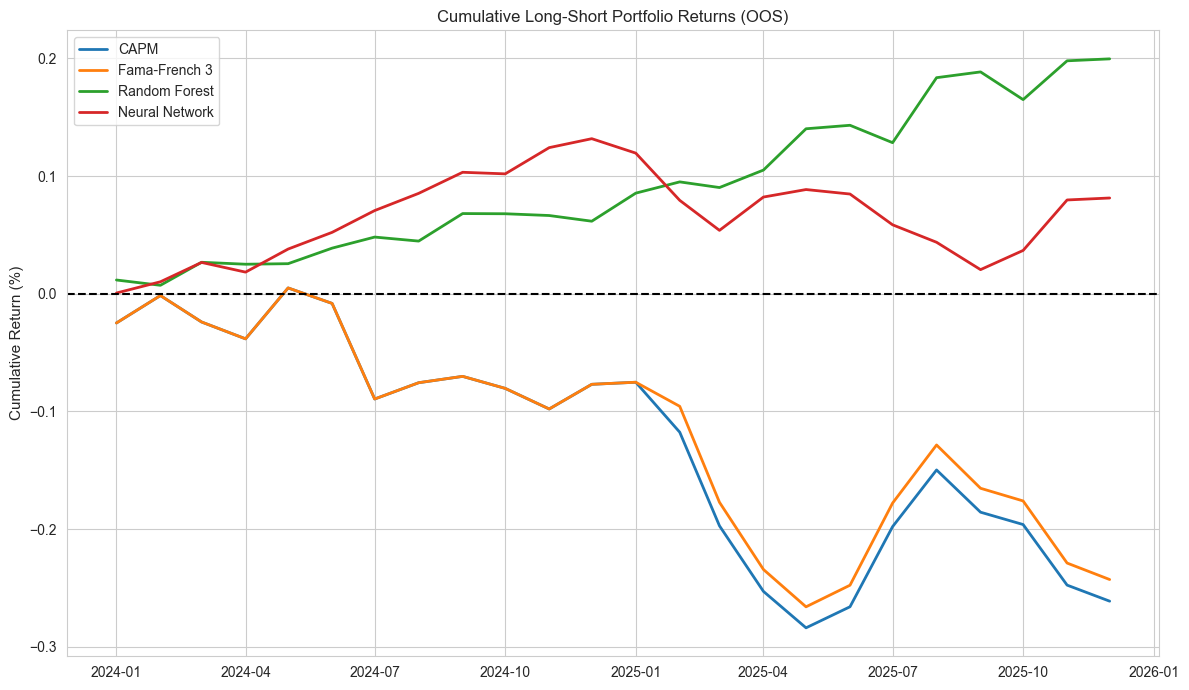

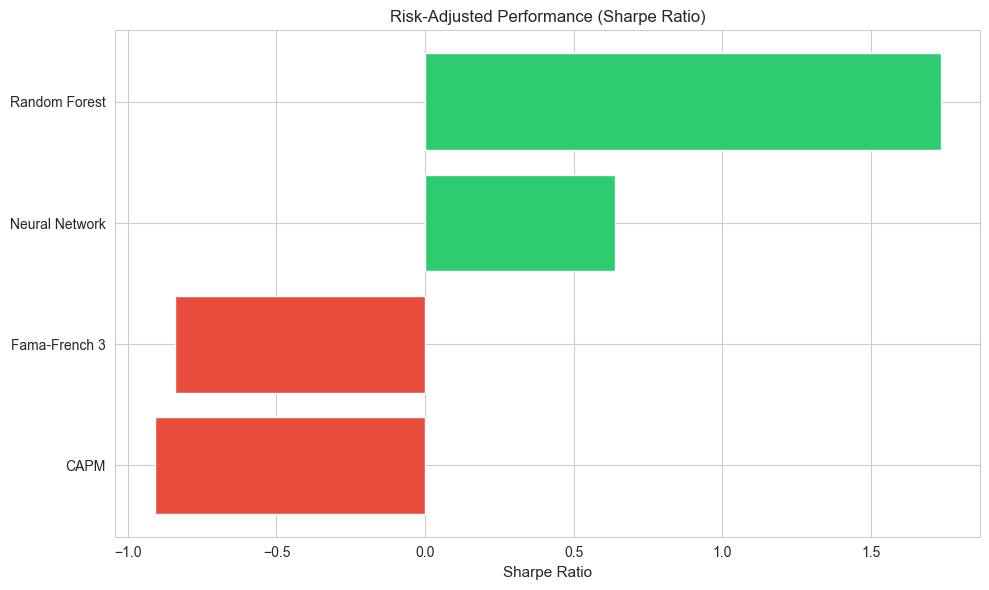

In [ ]:
OUT_DIR = r"./portfolio_performance"
os.makedirs(OUT_DIR, exist_ok=True)

MODELS = [
    {
        "name": "CAPM", 
        "path": "./sector_capm_outputs/sector_capm_predictions.csv", 
        "pred_col": "capm_pred_return", 
        "act_col": "actual_excess_return", 
        "level": "sector",
        "quantile": 0.33 
    },
    {
        "name": "Fama-French 3", 
        "path": "./sector_ff3_outputs/sector_ff3_predictions.csv", 
        "pred_col": "predicted_return",  
        "act_col": "actual_return", 
        "level": "sector",
        "quantile": 0.33
    },
    {
        "name": "Random Forest", 
        "path": "./sector_rf_outputs/sector_rf_predictions.csv", 
        "pred_col": "rf_pred", 
        "act_col": "excess_return", 
        "level": "ticker",
        "quantile": 0.20 
    },
    {
        "name": "Neural Network", 
        "path": "./sector_nn_outputs/sector_nn_predictions.csv", 
        "pred_col": "nn_pred", 
        "act_col": "excess_return", 
        "level": "ticker",
        "quantile": 0.20
    }
]

def calculate_drawdown(cumulative_returns):
    high_water_mark = cumulative_returns.cummax()
    drawdown = (cumulative_returns - high_water_mark) / high_water_mark
    return drawdown

def calculate_metrics(returns):
    ann_factor = 12
    mean_ret = returns.mean() * ann_factor
    volatility = returns.std() * np.sqrt(ann_factor)
    sharpe = mean_ret / volatility if volatility > 0 else np.nan
    
    neg_rets = returns[returns < 0]
    downside_std = neg_rets.std() * np.sqrt(ann_factor)
    sortino = mean_ret / downside_std if downside_std > 0 else np.nan
    
    cum_ret = (1 + returns).cumprod()
    dd = calculate_drawdown(cum_ret)
    max_dd = dd.min()
    
    return {
        "Annualized Return": mean_ret,
        "Annualized Volatility": volatility,
        "Sharpe Ratio": sharpe,
        "Sortino Ratio": sortino,
        "Max Drawdown": max_dd
    }

def construct_long_short_portfolio(df, config):
    date_col = "date"
    pred_col = config["pred_col"]
    act_col = config["act_col"]
    q = config["quantile"]
    
    # Robust Column Checking
    if pred_col not in df.columns or act_col not in df.columns:
        print(f"   [Error] Columns not found in {config['name']}. Expected: {[pred_col, act_col]}")
        print(f"   Available columns: {list(df.columns)}")
        return pd.DataFrame() 

    portfolio_returns = []
    
    for date, group in df.groupby(date_col):
        g = group.dropna(subset=[pred_col, act_col])
        if len(g) < 2: continue
        
        # Sort and Cut
        top_cutoff = g[pred_col].quantile(1 - q)
        bot_cutoff = g[pred_col].quantile(q)
        
        longs = g[g[pred_col] >= top_cutoff]
        shorts = g[g[pred_col] <= bot_cutoff]
        
        if longs.empty or shorts.empty: continue
            
        ret_long = longs[act_col].mean()
        ret_short = shorts[act_col].mean()
        
        portfolio_returns.append({
            "date": date,
            "Spread_Return": ret_long - ret_short
        })
        
    return pd.DataFrame(portfolio_returns).sort_values("date").set_index("date")

def run_evaluation():
    print("Starting Portfolio Evaluation...")
    all_metrics = []
    cumulative_returns = pd.DataFrame()
    
    for config in MODELS:
        print(f"Processing: {config['name']}...")
        if not os.path.exists(config["path"]):
            print(f"   Warning: File not found ({config['path']}). Skipping.")
            continue
            
        df = pd.read_csv(config["path"])
        
        # Robust Date Parsing
        if "date" not in df.columns and "YearMonth" in df.columns:
            df.rename(columns={"YearMonth": "date"}, inplace=True)
        df["date"] = pd.to_datetime(df["date"])
        
        port_ts = construct_long_short_portfolio(df, config)
        
        if port_ts.empty:
            print("   Warning: Could not construct portfolio (check columns or data size).")
            continue
            
        metrics = calculate_metrics(port_ts["Spread_Return"])
        metrics["Model"] = config["name"]
        all_metrics.append(metrics)
        
        # Store Cumulative P&L
        port_ts["Cumulative_Spread"] = (1 + port_ts["Spread_Return"]).cumprod() - 1
        cumulative_returns[config["name"]] = port_ts["Cumulative_Spread"]
        
        # Export Individual Time Series
        safe_name = config["name"].replace(" ", "_").replace("(", "").replace(")", "")
        port_ts.to_csv(os.path.join(OUT_DIR, f"{safe_name}_timeseries.csv"))
        
    if not all_metrics:
        print("No valid models found.")
        return

    metrics_df = pd.DataFrame(all_metrics).set_index("Model")
    print("\n--- Performance Summary ---")
    print(metrics_df)
    metrics_df.to_csv(os.path.join(OUT_DIR, "performance_summary.csv"))
    
    # Visualization
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    
    # Plotting charts
    for col in cumulative_returns.columns:
        plt.plot(cumulative_returns.index, cumulative_returns[col], label=col, linewidth=2)
    
    plt.title("Cumulative Long-Short Portfolio Returns (OOS)")
    plt.ylabel("Cumulative Return (%)")
    plt.legend()
    plt.axhline(0, color='black', linestyle='--')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "cumulative_returns_comparison.png"))
    
    # Sharpe Bar Chart
    plt.figure(figsize=(10, 6))
    metrics_sorted = metrics_df.sort_values("Sharpe Ratio", ascending=True)
    colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in metrics_sorted['Sharpe Ratio']]
    
    plt.barh(metrics_sorted.index, metrics_sorted['Sharpe Ratio'], color=colors)
    plt.title("Risk-Adjusted Performance (Sharpe Ratio)")
    plt.xlabel("Sharpe Ratio")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "sharpe_ratio_comparison.png"))
    
    print(f"\nResults saved to: {os.path.abspath(OUT_DIR)}")

if __name__ == "__main__":
    run_evaluation()